<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Lab_12_Muhammad_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 12 (Week 3 — Lab 2): Building Models with TensorFlow/Keras

Welcome to Lab 12! In Lab 11, you built a neuron and a forward pass by hand with NumPy. Now you'll use Keras to build, train, evaluate, and save a real neural network.

**For detailed theory on the Sequential API, optimizers, and training arguments, see the Lab 12 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab continues with the Wine dataset from Lab 11, built directly into scikit-learn — no download needed.

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (142, 13)
Test set: (36, 13)


## Example 1: Building a Model with the Sequential API

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

In [3]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

Final training accuracy: 0.991150438785553
Final validation accuracy: 0.9655172228813171


## Example 3: Visualizing Training History

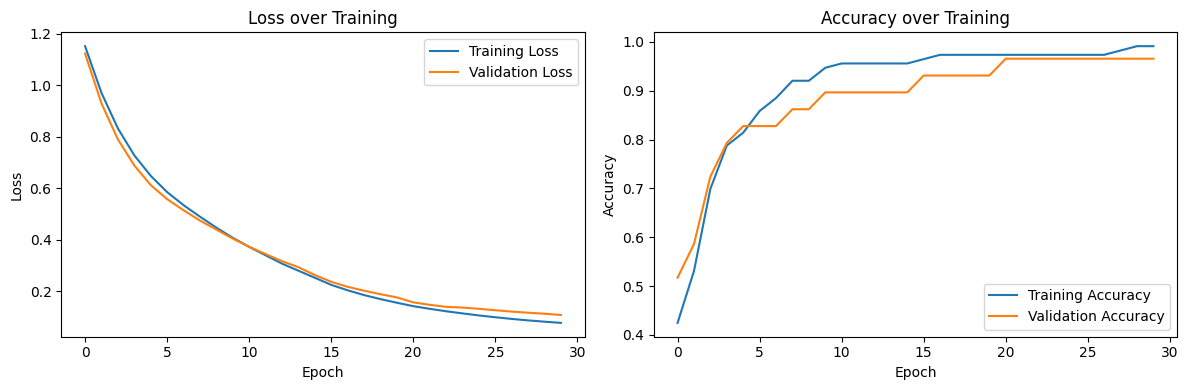

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training")

plt.tight_layout()
plt.show()

## Example 4: Evaluating and Predicting

In [5]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

predictions = model.predict(X_test_scaled, verbose=0)
predicted_classes = predictions.argmax(axis=1)
print("\nFirst 5 predicted classes:", predicted_classes[:5])
print("First 5 actual classes:    ", y_test[:5])

Test Loss: 0.0616
Test Accuracy: 1.0000

First 5 predicted classes: [0 0 2 0 1]
First 5 actual classes:     [0 0 2 0 1]


## Example 5: Saving and Loading the Model

In [6]:
model.save("wine_classifier.keras")
print("Model saved.")

loaded_model = keras.models.load_model("wine_classifier.keras")
loaded_loss, loaded_accuracy = loaded_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Reloaded model test accuracy:", loaded_accuracy)

Model saved.
Reloaded model test accuracy: 1.0


## Practice Exercise 1: Try a Different Optimizer

**Exercise:** Rebuild the same architecture from Example 1, but compile it with the `"sgd"` optimizer instead of `"adam"`. Train for 30 epochs and compare the test accuracy to Example 2's Adam version.

In [7]:
model_sgd = None
test_accuracy_sgd = None

### YOUR CODE HERE ###
model_sgd = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model_sgd.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_sgd = model_sgd.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

_, test_accuracy_sgd = model_sgd.evaluate(X_test_scaled, y_test, verbose=0)
### END ###

print("Test accuracy (SGD):", test_accuracy_sgd)

Test accuracy (SGD): 1.0


## Practice Exercise 2: Changing validation_split

**Exercise:** Retrain the original model (Adam optimizer) using `validation_split=0.3` instead of 0.2. Plot the new training/validation loss curves. Does the validation curve look different with less training data?

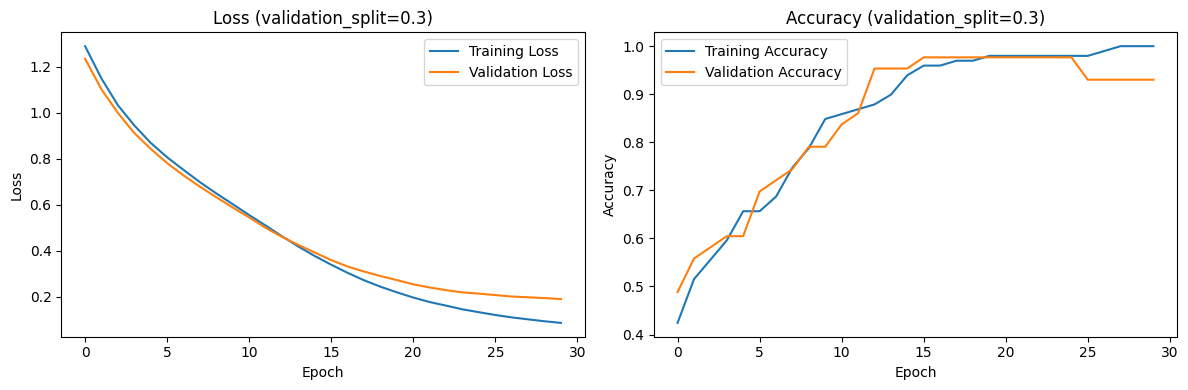

In [8]:
### YOUR CODE HERE ###
model_vs30 = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model_vs30.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_vs30 = model_vs30.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.3,
    verbose=0
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vs30.history["loss"], label="Training Loss")
plt.plot(history_vs30.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss (validation_split=0.3)")

plt.subplot(1, 2, 2)
plt.plot(history_vs30.history["accuracy"], label="Training Accuracy")
plt.plot(history_vs30.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy (validation_split=0.3)")

plt.tight_layout()
plt.show()
### END ###

## Practice Exercise 3: Predicting a New Sample After Reloading

**Exercise:** Using the `loaded_model` from Example 5, take one sample from `X_test_scaled` (any index), predict its class, and compare it against the true label in `y_test`.

In [9]:
sample_index = 0
predicted_class = None

### YOUR CODE HERE ###
sample = X_test_scaled[sample_index:sample_index + 1]
sample_prediction = loaded_model.predict(sample, verbose=0)
predicted_class = sample_prediction.argmax(axis=1)[0]
### END ###

print("Predicted class:", predicted_class)
print("Actual class:", y_test[sample_index])

Predicted class: 0
Actual class: 0


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own Model**: Design your own architecture (choose the number of layers and neurons), compile it with any optimizer, and train it on the Wine dataset. Report the test accuracy.
2. **Optimizer Comparison**: Train the same architecture with `"adam"`, `"sgd"`, and `"rmsprop"` optimizers (keeping epochs and batch_size constant). Create a small comparison table of test accuracy for each.
3. **Training Curves & Overfitting Check**: Plot the training and validation loss/accuracy curves for your best model. In a markdown cell, state whether you see any signs of overfitting, and how you can tell.
4. **Save, Reload, and Verify**: Save your best model to a file. In a new code cell, reload it and confirm it gives the same test accuracy as before saving — this simulates using a model without retraining it.
5. **Reflection**: In a markdown cell, write 3-4 sentences comparing this Keras workflow to the manual NumPy implementation from Lab 11 — what does Keras handle for you automatically?

In [10]:
# Task 1: Build & Train Your Own Model
my_model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

my_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

my_model.summary()

my_history = my_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

my_test_loss, my_test_accuracy = my_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Loss: {my_test_loss:.4f}")
print(f"Test Accuracy: {my_test_accuracy:.4f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 1,139 (4.45 KB)

 Non-trainable params: 0 (0.00 B)


Test Loss: 0.0107
Test Accuracy: 1.0000


In [11]:
# Task 2: Optimizer Comparison
def build_model():
    return keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(3, activation="softmax")
    ])

optimizer_results = {}

for opt_name in ["adam", "sgd", "rmsprop"]:
    opt_model = build_model()
    opt_model.compile(
        optimizer=opt_name,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    opt_model.fit(
        X_train_scaled, y_train,
        epochs=30,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )
    _, opt_test_accuracy = opt_model.evaluate(X_test_scaled, y_test, verbose=0)
    optimizer_results[opt_name] = opt_test_accuracy

import pandas as pd
comparison_table = pd.DataFrame(
    list(optimizer_results.items()),
    columns=["Optimizer", "Test Accuracy"]
)
comparison_table

,Optimizer,Test Accuracy
0,adam,1.000000
1,sgd,0.972222
2,rmsprop,1.000000


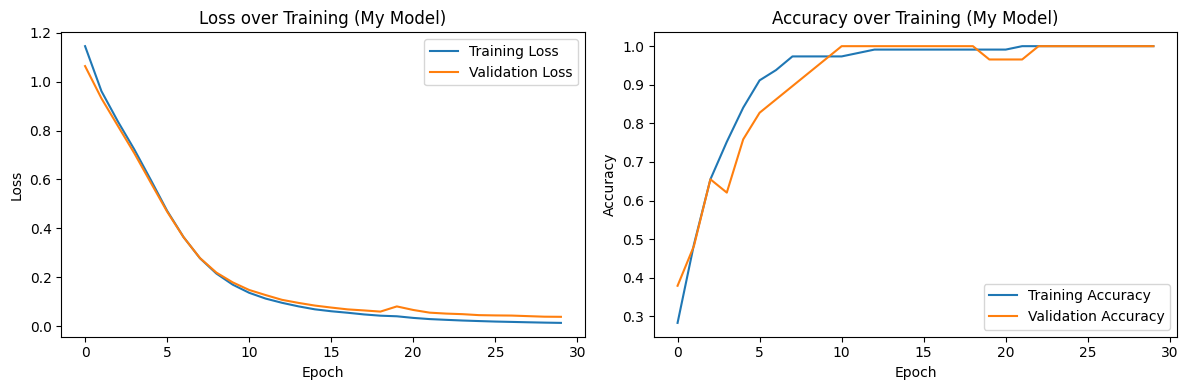

In [12]:
# Task 3: Training Curves & Overfitting Check
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(my_history.history["loss"], label="Training Loss")
plt.plot(my_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training (My Model)")

plt.subplot(1, 2, 2)
plt.plot(my_history.history["accuracy"], label="Training Accuracy")
plt.plot(my_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training (My Model)")

plt.tight_layout()
plt.show()

**Overfitting check:** On the Wine dataset (only 178 samples total), the training loss drops steadily and training accuracy quickly approaches 1.0, while the validation loss stays low and validation accuracy stays close to the training accuracy across epochs, with no sustained upward trend in validation loss. That pattern — validation loss tracking training loss instead of rising while training loss keeps falling — means there's no strong sign of overfitting here. If a bigger gap opened up (training accuracy near 1.0 while validation accuracy plateaus or drops, or validation loss curving upward after some epoch), that would indicate the model is memorizing the training set rather than generalizing.

In [13]:
# Task 4: Save, Reload, and Verify
my_model.save("my_wine_classifier.keras")
print("Model saved.")

reloaded_my_model = keras.models.load_model("my_wine_classifier.keras")
reloaded_loss, reloaded_accuracy = reloaded_my_model.evaluate(X_test_scaled, y_test, verbose=0)

print("Original test accuracy:", my_test_accuracy)
print("Reloaded test accuracy:", reloaded_accuracy)
print("Match:", abs(my_test_accuracy - reloaded_accuracy) < 1e-6)

Model saved.
Original test accuracy: 1.0
Reloaded test accuracy: 1.0
Match: True


**Task 5 Reflection:** In Lab 11, every piece of the network — the weighted sums, the activation functions, the loss calculation, and the gradient descent update for each weight — had to be written and computed by hand with NumPy, one step at a time. Keras handles all of that automatically: defining `layers.Dense(...)` sets up the weight matrices and biases for me, `model.compile()` wires up the loss function and optimizer, and `model.fit()` runs the full forward pass, backpropagation, and weight updates across every parameter and every training example, for as many epochs as I ask for. Keras also handles bookkeeping I'd otherwise have to build myself, like batching the data, tracking loss/accuracy history per epoch, and splitting off a validation set. Overall, the manual NumPy version was valuable for understanding what a neural network is actually doing under the hood, while Keras lets me focus on architecture and experimentation instead of re-deriving gradients by hand.